[![](https://github.com/ElleNajt/ob-python-extras/actions/workflows/org_babel_tests.yml/badge.svg)](https://github.com/ElleNajt/ob-python-extras/actions/workflows/org_babel_tests.yml/badge.svg)

This package adds additional features to ob-python that I found lacking
when trying to use it as a replacement for jupyter notebooks. I've been
using it instead of jupyter notebooks for about a year now, slowly
accumulating fixes to things that I miss from jupyter, or things that
seem cool that jupyter doesn't support but emacs makes easy.

# Features:

## Enhanced cell output

-   Mix image and text output in the same cell, by mocking matplotlib to
    save images and return references.

-   Print pandas dataframes as org tables always, by overwriting the
    <u><u>repr</u></u> method. Uses tabulate if available.

-   Press C-c C-c over an image for a full-size view

    For example:

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.DataFrame({"x": [1, 2, 3, 4, 5,6,7,], "y": [10, 11, 12, 13, 14,15,16]})
print(df)
df.plot(x="x", y="y", kind="line")
plt.show()
print("...tada!")


| idx | x   | y   |
|-----|-----|-----|
| 0   | 1   | 10  |
| 1   | 2   | 11  |
| 2   | 3   | 12  |
| 3   | 4   | 13  |
| 4   | 5   | 14  |
| 5   | 6   | 15  |
| 6   | 7   | 16  |

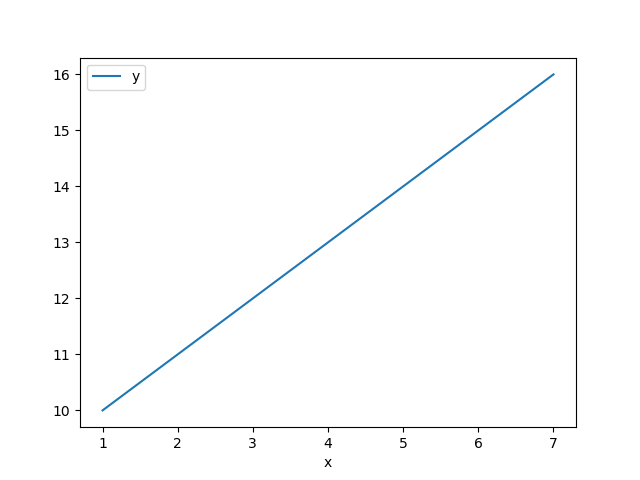

…tada!

## Cell behavior features

-   Cell timers (configurable via :timer-show {yes/no})
-   Last run time (configurable via :last-executed {yes/no})
-   Cell interruption with C-c C-k
-   Capturing tracebacks in the results (with the option to use rich
    tracebacks via header-args like :errors "rich no-locals frames 3
    extra 5")
-   Alerts on long running cells, using libnotify for system alerts and
    pop ups inside of doom
-   Open the session in another buffer (Keybindings bind it to SPC o s)
-   Variable inspector (Keybindings bind it to SPC o v)
-   Limit output with :max-lines (POSITIVE-INTEGER) – useful because
    very long output can crash org babel, so it's useful to set this to
    :max-lines 1000 or similar and just inspect the shell (easily
    accessible with SPC o s).
-   Print the last expressions result

## Bare bones LSP features <span class="tag" tag-name="ATTACH"><span class="smallcaps">ATTACH</span></span>

-   ob-python-extras/python-help-clean

This calls the python REPL's help on the current symbol (obtained from
(python-info-current-symbol)). The defaults bind it to K
(lookup/documentation)

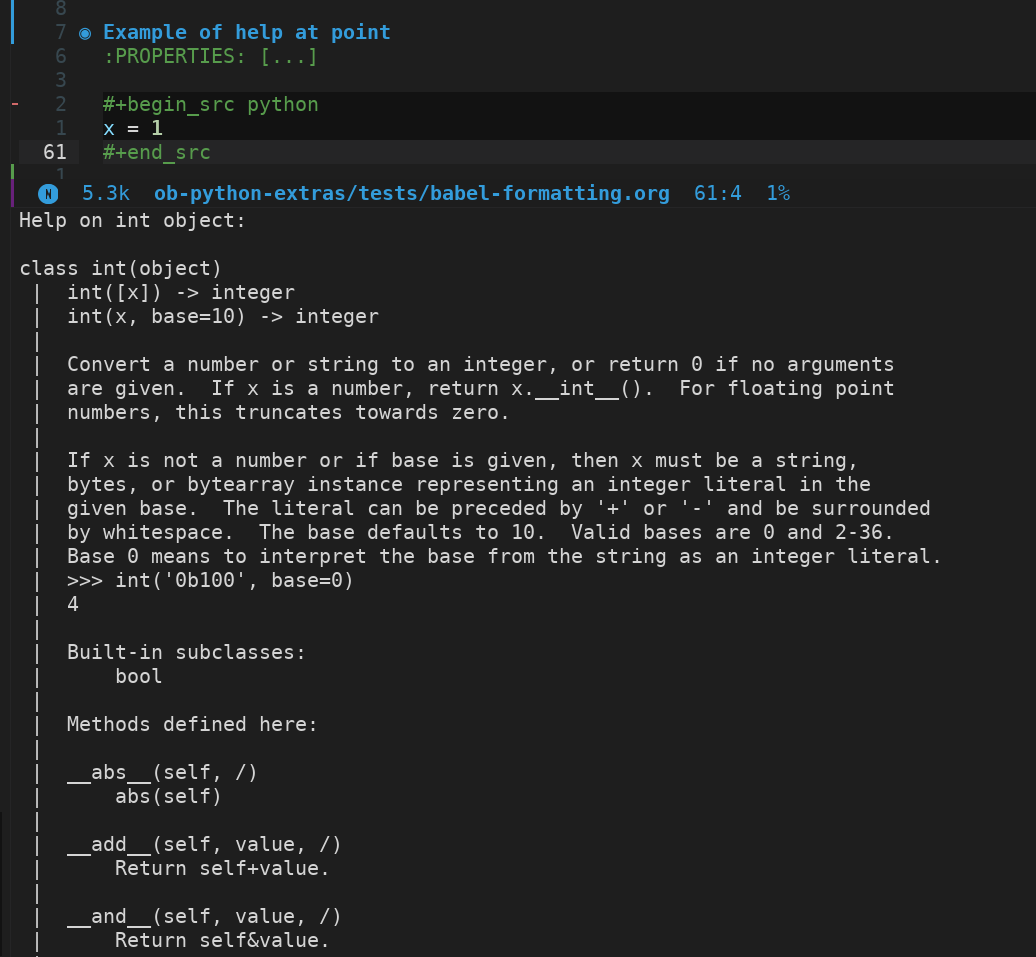

-   ob-python-extras/goto-definition

    Similarly, this uses pythons inspect to find the path for the object
    at point, then travels there. Default bound to gd.

-   Completion at point

    Gets completion at point via the python process corresponding to a
    cell, and feeds them into capf.

    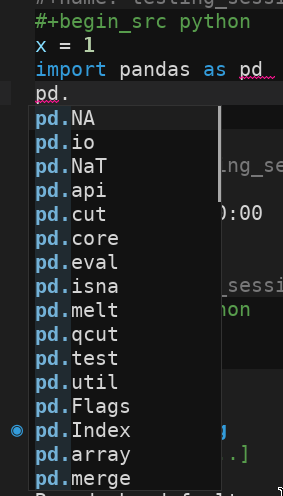

## Gptel integrations:

This was moved into ElleNajt/gpt-babel to handle more soruce blocks than
just python.

## HTML Output conversion

Uses pandoc to convert HTML output into org, with some clean up to
prevent it from breaking output drawer results block formatting.

## Variable Renamer Utility

Tooling to safely rename variables in an org file across all python
blocks that have valid python syntax. (python blocks with invalid syntax
will be skipped.)

To use, create a renamer.json in the same folder as your .org file, mark
both with dired, and then run ob-python-extras/dired-rename-python-vars.

By default this runs a python via "nix-shell –pure -p black –run 'python
…'" , set the variable alternative-python-binary to a different python
binary if not using nix.

## Pandoc scripts:

Configured scripts for converting org files in a directory to ipynb
files, or ipynb files to org files. These rely on pandoc.

These commands are intended to be called from dired buffers.

`run-ipynb-to-org-conversion-script`  
Convert all .ipynb files in current directory to .org (removes various
artifacts that pandoc creates also, cleaning can be disabled by removing
the -c flag)

`run-ipynb-to-org-conversion-script-recursively`  
Convert all .ipynb files in current directory and subdirectories to .org

`run-org-to-ipynb-conversion-script`  
Convert all .org files in current directory to .ipynb

Also includes a git precommit hook that's useful for automatically
converting org to ipynb.

# Dependencies

-   Python packages: Rich, tabulate (optional, but recommended),
    matplotlib
-   System: Libnotify (for alerts), Pandoc (For conversions)
-   Emacs: Doom (for now required for alerts), Eglot (for lsp
    integrations), Dired (For the conversion scripts)

# Installation

## With straight.el

``` commonlisp
(package! ob-python-extras
  :recipe (:host github
           :repo "ElleNajt/ob-python-extras"
           :files ("*.el" "python" "bashscripts")))
```

# Setup:

## Garbage collection

By default garbage collection is disabled. To turn it on, set:

``` commonlisp
(setq ob-python-extras/allow-png-deletion t)
```

Then, every 5 minutes, a script will run that collects all the open org
files, and checks the folders in /plots/{buffer<sub>name</sub>} where
the images are stored, and deletes those that are not referenced.

### <span class="todo TODO">TODO</span> Modify the html conversion stuff to go in the same folder

## Keybindings:

If you want my keybindings, run:

``` commonlisp
(ob-python-extras-load-keybindings)
```

No keybindings are set otherwise, to prevent conflicts with users
configs.

## Setting up alert integrations

``` commonlisp
(after! ob-python-extras
  (ob-python-extras-load-alerts))
```

## Matplotlib image transparency

Matplotlib is configured to save and display images without transparency
by default. The default can be changed with `(setq
ob-python-extras/transparent-images t)`. This default, in turn, can be
overridden at the org-src-block level with `:transparent nil` or
`:transparent
t`.

## Autoformatter

Auto formats source blocks using black and isort. Can be turned on and
off with:

``` elisp
(setq ob-python-extras/auto-format t)
```

This requires isort to be available on your path, and to configure
python-black.

``` commonlisp
(package! python-black)
(use-package! python-black
  :after python)
```

# Examples:

[See this org file for examples of the different functionality and
configurations.](tests/babel-formatting.org)

# Other notes:

In my personal config I use the following keybindings as well, based on
a vendored version guilt-dolphin's org-evil with keybindings stripped.
These make it easier to manipulate source blocks:

``` commonlisp

(org-evil--define-key 'motion 'org-evil-motion-mode
                      "[[" 'org-evil-motion-backward-block-begin
                      "]]" 'org-evil-motion-forward-block-begin)

(add-hook! 'org-mode-hook 'org-evil-mode)

(undefine-key! evil-motion-state-map "[ s" "] s")

(map! (:mode org-mode
       :n "] r" #'org-babel-goto-src-block-results
       :n "[ s" 'org-evil-block-beginning-of-block
       :n "] s" 'org-evil-block-end-of-block))

(org-evil--define-key 'motion 'org-evil-block-mode
                      "[ s" 'org-evil-block-beginning-of-block
                      "] s" 'org-evil-block-end-of-block)

(dolist (mode '(operator visual))
  (org-evil--define-key mode 'org-evil-block-mode
                        "ib" 'org-evil-block-inner-block
                        "ab" 'org-evil-block-a-block))
```

# Credit:

-   Aspen for teaching me a bunch about emacs and suggesting mocking out
    matplotlib
-   Claude for writing most of the code ^^

# Related packages:

## Emacs jupyter

<https://github.com/emacs-jupyter/jupyter> This package provides some
overlapping functionality, and as far as I understand it does it by
connecting to jupyter kernels and providing a front end in org mode for
the kernel. I have not used this myself yet.

On the other hand, getting emacs-jupyter set up seems difficult to many
people, including me, so having a simpler package that makes python
babel cells more powerful is also useful.

### Scimax also uses emacs jupyter

## ob-ipython

## EIN

<https://github.com/millejoh/emacs-ipython-notebook> Similar to
Emacs-Jupyter. No longer maintained.